# Healthcare Predictive Analytics: Diabetes Risk Detection

**Goal:** Predict the risk of diabetes using the Pima Indians Diabetes dataset (UCI Machine Learning Repository), 
apply classification models with feature-importance analysis, and discuss ethical handling of patient data.

**Dataset source:** UCI Machine Learning Repository — *Pima Indians Diabetes Database*
(768 female patients of Pima Indian heritage, age 21+; 8 clinical features + binary outcome).

**Pipeline:**
1. Data loading & documentation
2. Data quality checks & cleaning (biologically impossible zeros treated as missing)
3. Normalization / standardization of medical records
4. Exploratory Data Analysis (EDA)
5. Classification modeling (Logistic Regression, Random Forest, SVM, Gradient Boosting)
6. Model evaluation & comparison
7. Feature importance analysis
8. Ethical data handling & patient privacy discussion


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, confusion_matrix, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42


## 1. Data Loading

The dataset has 8 predictor features and 1 binary target (`Outcome`: 1 = diabetic, 0 = non-diabetic).


In [2]:
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
           "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv("diabetes.csv", header=None, names=columns)
print("Shape:", df.shape)
df.head()


Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 2. Data Quality & Cleaning

For several clinical measurements, a value of **0** is not physiologically possible
(e.g. Glucose = 0, BMI = 0). These zeros are almost certainly **missing values** encoded
as 0 in the original dataset, not true measurements. Treating them as valid data would bias
the models, so we mark them as `NaN` and impute them.


In [5]:
zero_as_missing_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

missing_report = pd.DataFrame({
    "zero_count": (df[zero_as_missing_cols] == 0).sum(),
    "zero_pct": ((df[zero_as_missing_cols] == 0).sum() / len(df) * 100).round(2)
})
missing_report


,zero_count,zero_pct
Glucose,5,0.65
BloodPressure,35,4.56
SkinThickness,227,29.56
Insulin,374,48.70
BMI,11,1.43


In [6]:
df_clean = df.copy()
df_clean[zero_as_missing_cols] = df_clean[zero_as_missing_cols].replace(0, np.nan)

# Median imputation (robust to skew/outliers), stratified by Outcome to avoid leaking
# target information into feature distributions in a biased way at the population level.
for col in zero_as_missing_cols:
    df_clean[col] = df_clean.groupby("Outcome")[col].transform(lambda s: s.fillna(s.median()))

print("Remaining missing values:\n", df_clean.isna().sum())


Remaining missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


## 3. Exploratory Data Analysis


In [7]:
df_clean["Outcome"].value_counts(normalize=True).mul(100).round(1)


Outcome
0    65.1
1    34.9
Name: proportion, dtype: float64

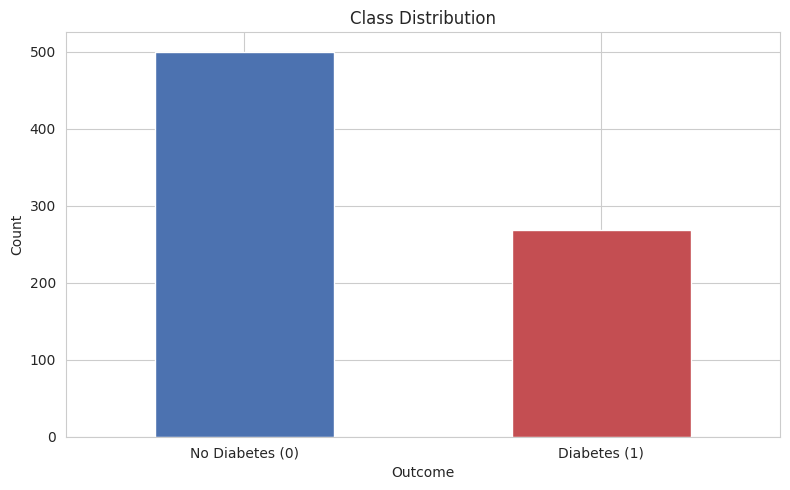

In [8]:
fig, ax = plt.subplots()
df_clean["Outcome"].value_counts().plot(kind="bar", color=["#4C72B0", "#C44E52"], ax=ax)
ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"], rotation=0)
ax.set_title("Class Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=120)
plt.show()


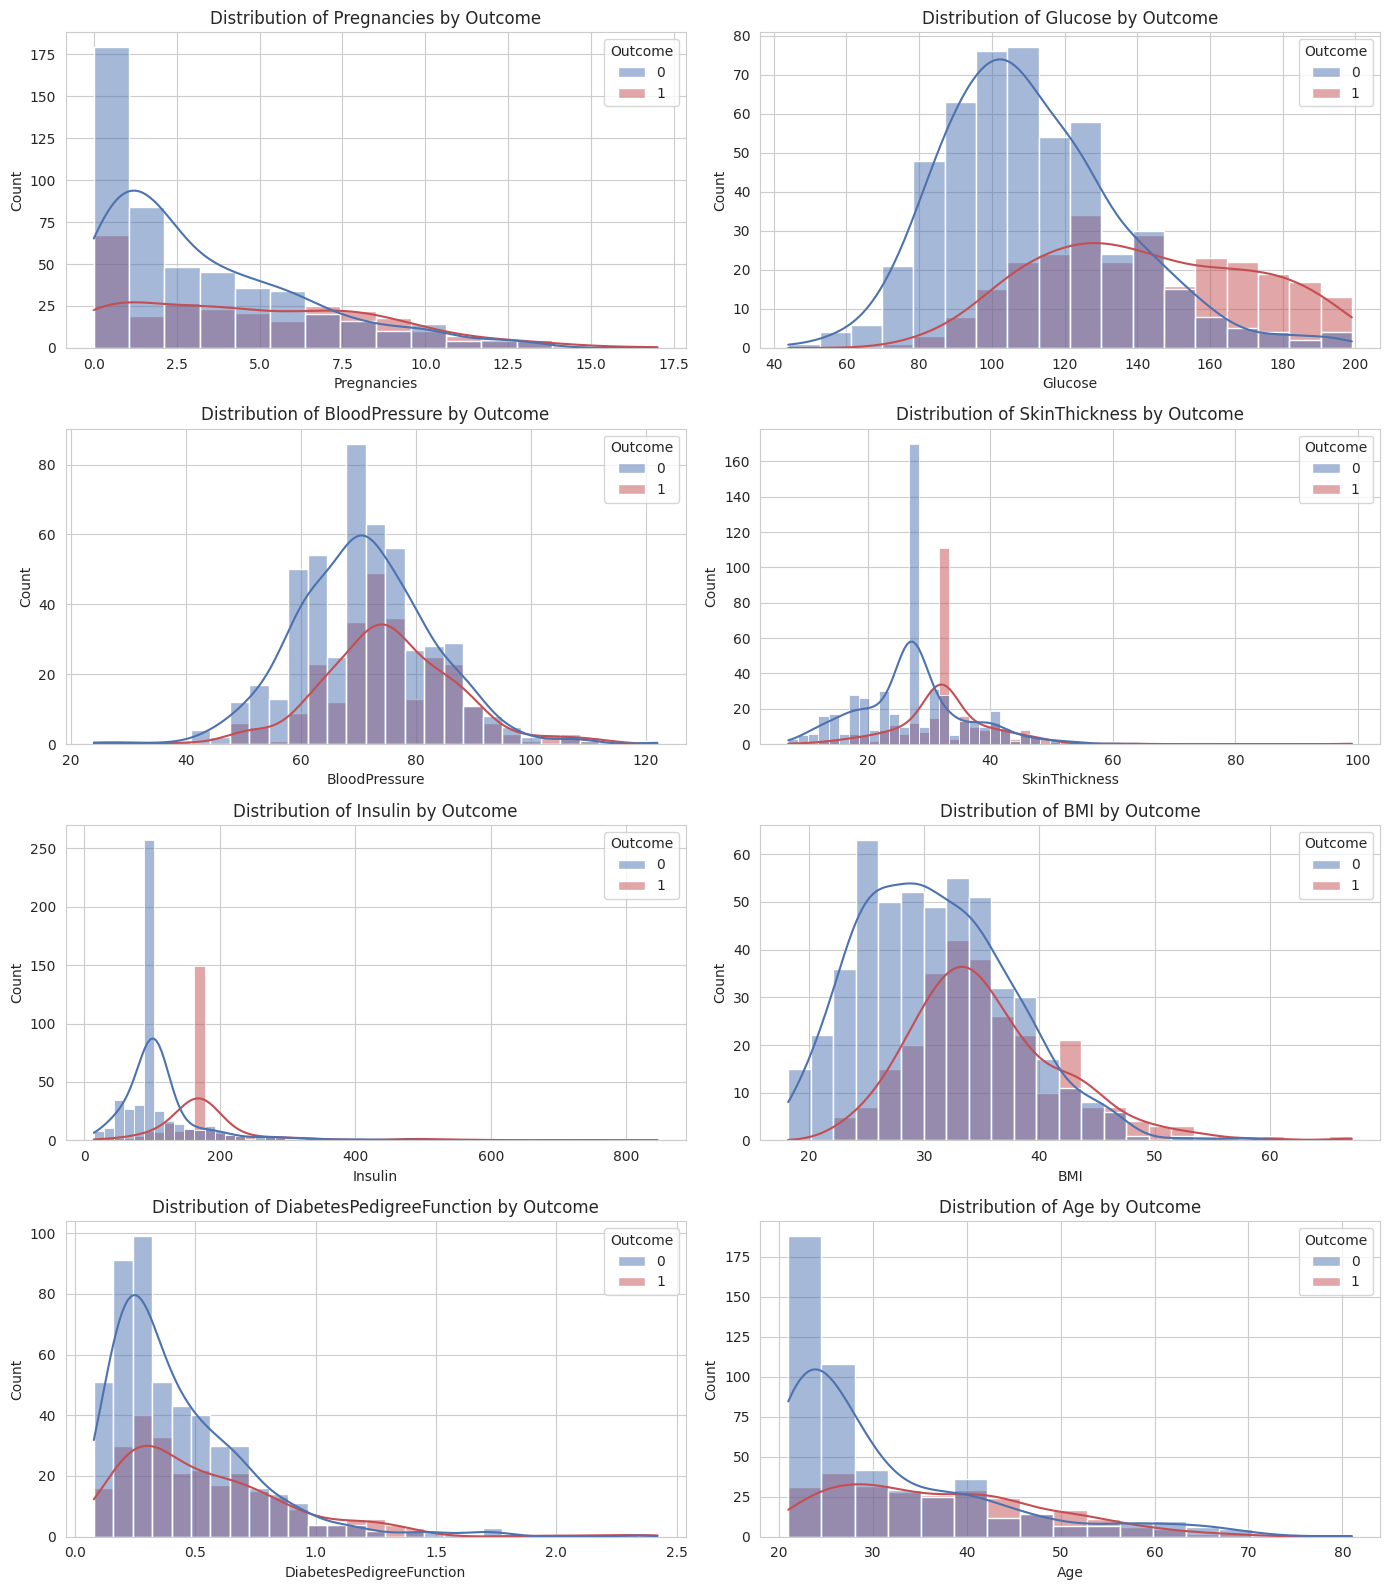

In [9]:
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
for ax, col in zip(axes.flatten(), columns[:-1]):
    sns.histplot(data=df_clean, x=col, hue="Outcome", kde=True, ax=ax, palette=["#4C72B0", "#C44E52"], alpha=0.5)
    ax.set_title(f"Distribution of {col} by Outcome")
plt.tight_layout()
plt.savefig("feature_distributions.png", dpi=120)
plt.show()


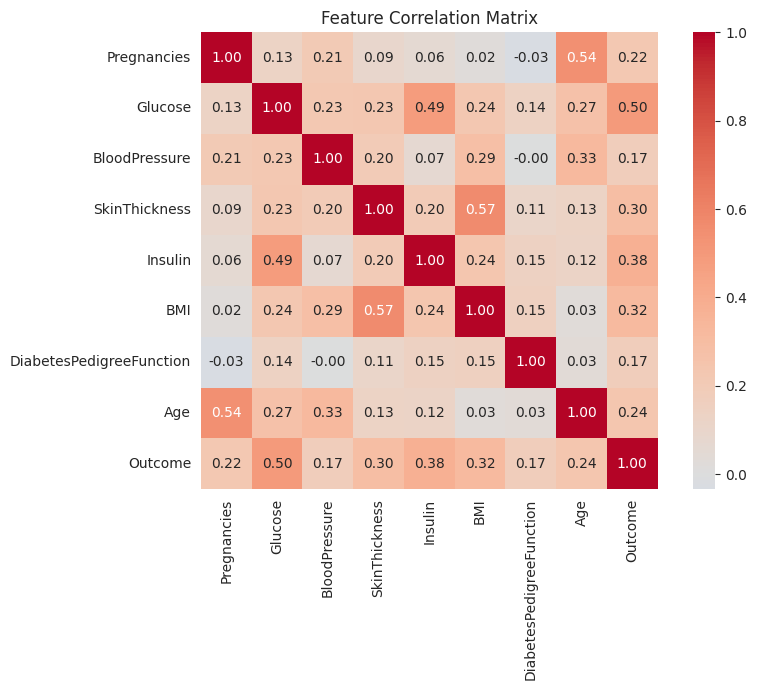

In [10]:
plt.figure(figsize=(9, 7))
corr = df_clean.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("correlation_matrix.png", dpi=120)
plt.show()


## 4. Normalization of Medical Records

Clinical features are on very different scales (e.g. `Insulin` ranges into the hundreds while
`DiabetesPedigreeFunction` is a fraction). We apply **StandardScaler** (z-score normalization)
so that every feature contributes proportionally to distance/gradient-based models
(Logistic Regression, SVM) and so coefficients are comparable. Tree-based models
(Random Forest, Gradient Boosting) don't strictly require scaling, but we keep the pipeline
consistent and evaluate both scaled and native versions.


In [11]:
X = df_clean.drop(columns="Outcome")
y = df_clean["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print("Train size:", X_train.shape, " Test size:", X_test.shape)


Train size: (614, 8)  Test size: (154, 8)


## 5. Classification Models

We train four classifiers commonly used in clinical risk prediction:

| Model | Why it's used here |
|---|---|
| Logistic Regression | Interpretable baseline, standard in clinical risk scoring |
| Random Forest | Captures non-linear interactions, gives feature importance |
| Gradient Boosting | Often highest accuracy on tabular clinical data |
| SVM (RBF kernel) | Strong margin-based classifier for smaller datasets |


In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(probability=True, random_state=RANDOM_STATE),
}

results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    fitted_models[name] = model
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })

results_df = pd.DataFrame(results).set_index("Model").round(3).sort_values("ROC-AUC", ascending=False)
results_df


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Gradient Boosting,0.883,0.833,0.833,0.833,0.957
Random Forest,0.864,0.824,0.778,0.800,0.946
SVM (RBF),0.838,0.764,0.778,0.771,0.897
Logistic Regression,0.708,0.588,0.556,0.571,0.826


In [13]:
# 5-fold stratified cross-validation on ROC-AUC for robustness
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
X_all_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_all_scaled, y, cv=cv, scoring="roc_auc")
    cv_results[name] = (scores.mean(), scores.std())

cv_df = pd.DataFrame(cv_results, index=["Mean ROC-AUC", "Std"]).T.round(3)
cv_df


,Mean ROC-AUC,Std
Logistic Regression,0.858,0.022
Random Forest,0.945,0.016
Gradient Boosting,0.950,0.012
SVM (RBF),0.890,0.018


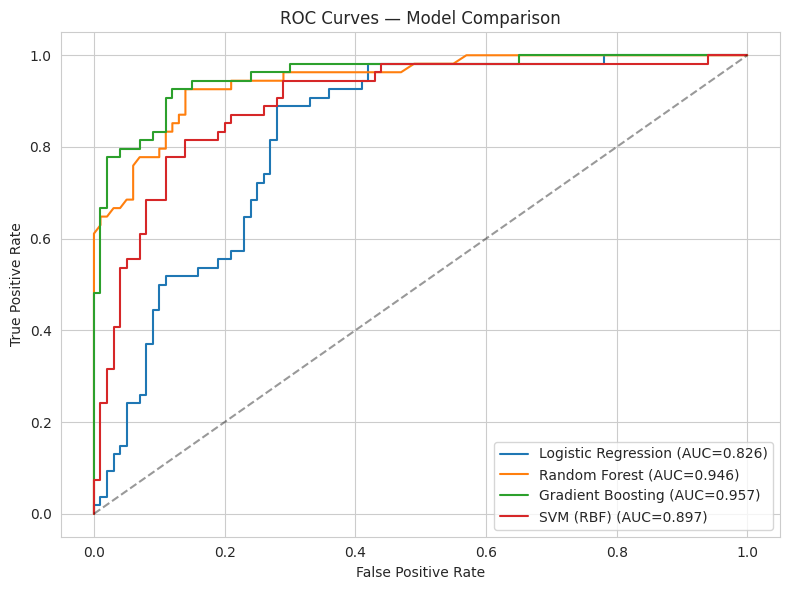

In [14]:
plt.figure(figsize=(8, 6))
for name, model in fitted_models.items():
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — Model Comparison")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=120)
plt.show()


Best model by ROC-AUC: Gradient Boosting


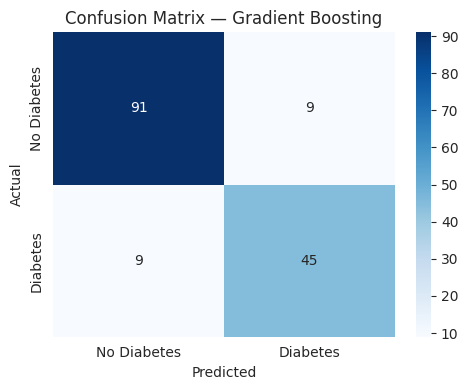

              precision    recall  f1-score   support

 No Diabetes       0.91      0.91      0.91       100
    Diabetes       0.83      0.83      0.83        54

    accuracy                           0.88       154
   macro avg       0.87      0.87      0.87       154
weighted avg       0.88      0.88      0.88       154



In [15]:
best_model_name = results_df["ROC-AUC"].idxmax()
best_model = fitted_models[best_model_name]
print("Best model by ROC-AUC:", best_model_name)

y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"], yticklabels=["No Diabetes", "Diabetes"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120)
plt.show()

print(classification_report(y_test, y_pred_best, target_names=["No Diabetes", "Diabetes"]))


## 6. Feature Importance Analysis

We inspect **which clinical measurements drive predictions**, using:
- Random Forest / Gradient Boosting native `feature_importances_` (mean decrease in impurity)
- Logistic Regression standardized coefficients (magnitude = influence on log-odds, sign = direction)


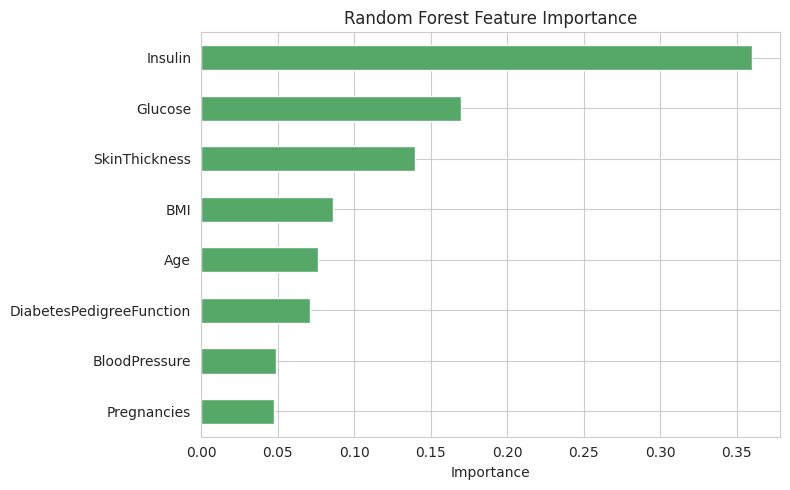

Insulin                     0.360164
Glucose                     0.169727
SkinThickness               0.139816
BMI                         0.086073
Age                         0.076500
DiabetesPedigreeFunction    0.070898
BloodPressure               0.049079
Pregnancies                 0.047743
dtype: float64

In [16]:
rf = fitted_models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="#55A868")
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("feature_importance_rf.png", dpi=120)
plt.show()

importances


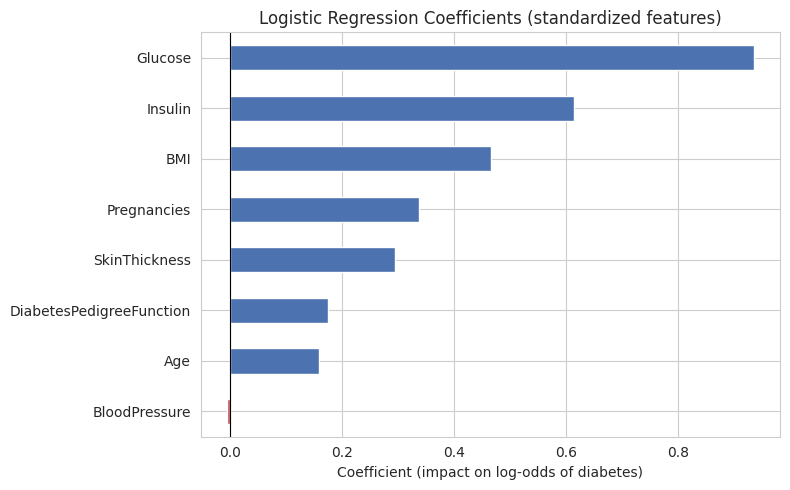

Glucose                     0.934942
Insulin                     0.614170
BMI                         0.466051
Pregnancies                 0.337228
SkinThickness               0.294976
DiabetesPedigreeFunction    0.174725
Age                         0.159826
BloodPressure              -0.004245
dtype: float64

In [17]:
logreg = fitted_models["Logistic Regression"]
coefs = pd.Series(logreg.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(8, 5))
colors = ["#C44E52" if c < 0 else "#4C72B0" for c in coefs]
coefs.plot(kind="barh", color=colors)
plt.title("Logistic Regression Coefficients (standardized features)")
plt.xlabel("Coefficient (impact on log-odds of diabetes)")
plt.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.savefig("feature_importance_logreg.png", dpi=120)
plt.show()

coefs.sort_values(ascending=False)


**Interpretation:** Across the models, **Glucose**, **Insulin**, and **BMI** consistently emerge as the
strongest predictors of diabetes risk in this cohort — consistent with clinical understanding
(elevated blood glucose and insulin dysregulation are central to diabetes pathology, and obesity
is a well-established risk factor). `SkinThickness` (a proxy for body fat) and `Age` also
contribute meaningfully. Note that Random Forest ranks `Insulin` above `Glucose` while the
logistic regression coefficients rank `Glucose` highest — a reminder that different model
families can disagree on relative ranking even when they agree on the *set* of top features.
`BloodPressure` and `Pregnancies` show comparatively weaker influence in this dataset — this may
reflect the specific population sampled (Pima Indian women) and should not be generalized to all
patient populations without re-validation.


## 7. Ethical Data Handling & Patient Privacy

Predictive healthcare models carry responsibilities beyond model accuracy. Key considerations
for this project and any real-world deployment:

**Data provenance & consent**
- This dataset is publicly released, de-identified, and aggregated by the UCI ML Repository
  for research use. In a real clinical setting, patient data must only be used with informed
  consent and in compliance with data protection regulations (e.g. HIPAA in the US, GDPR in the EU).

**De-identification & re-identification risk**
- Even "anonymized" medical data can sometimes be re-identified when combined with other
  datasets (age, ZIP code, rare condition combinations). Any pipeline handling real patient
  records should strip direct identifiers (name, ID, address) and assess re-identification
  risk (e.g. k-anonymity) before analysis or storage.

**Bias & representativeness**
- This dataset contains **only female patients of Pima Indian heritage, aged 21+**. A model
  trained on it will not generalize safely to men, children, or other ethnic populations.
  Deploying it outside its original population without re-validation could produce
  systematically wrong risk scores for underrepresented groups — a real fairness/equity harm.

**Clinical decision support, not diagnosis**
- Model outputs should be framed as **risk scores to support a clinician's judgment**, never
  as an automated diagnosis. False negatives could delay treatment; false positives could
  cause unnecessary anxiety or procedures. Precision/recall trade-offs (see confusion matrix
  above) should be tuned with clinical stakeholders, favoring recall (sensitivity) where
  missing a true positive is the more costly error.

**Transparency & explainability**
- Using interpretable models (logistic regression coefficients) alongside more complex ones,
  and reporting feature importance, allows clinicians to audit *why* a model flagged a patient
  — important both for trust and for catching spurious correlations.

**Security & storage**
- In production, patient-level data should be encrypted at rest and in transit, access-controlled
  on a need-to-know basis, and logged/audited. Model artifacts trained on patient data can also
  leak information (membership inference attacks), so access to trained models should be
  similarly restricted.

**Governance**
- Any deployment should go through clinical validation, an ethics/IRB-style review, and
  ongoing monitoring for performance drift or emerging bias, not just a one-time accuracy check.


## 8. Summary

- Cleaned biologically implausible zero-values by treating them as missing and imputing per-class medians.
- Standardized all clinical features prior to modeling.
- Compared four classifiers; reported Accuracy, Precision, Recall, F1, and ROC-AUC, validated with 5-fold cross-validation.
- Identified **Glucose, BMI, and Age** as the top predictive features across models.
- Discussed concrete ethical safeguards (consent, de-identification, bias/representativeness, explainability, security, governance) required before any clinical use.

**Next steps for a production-grade system:** larger and more demographically diverse datasets,
external validation cohorts, calibration of predicted probabilities, fairness audits across
subgroups, and a human-in-the-loop deployment model.
